# Dawid–Skene EM

In [1]:
import os, re, json, math
from typing import List, Tuple
import numpy as np
import pandas as pd

CLASSES = ["High","Good","Moderate","Bad","Poor"]
C = len(CLASSES)
CLS_TO_ID = {c:i for i,c in enumerate(CLASSES)}

def tidy_label(x):
    if x is None or (isinstance(x,float) and pd.isna(x)): return None
    s = str(x).strip().lower().replace('_',' ').replace('-',' ')
    s = s.title()
    aliases = {"High":"High","Good":"Good","Moderate":"Moderate","Bad":"Bad","Poor":"Poor"}
    return aliases.get(s, None)

def entropy(p: np.ndarray) -> float:
    q = np.clip(p, 1e-12, 1.0)
    return float(-np.sum(q*np.log(q)))


In [2]:
def infer_label_column(df: pd.DataFrame) -> str:
    # prefer a single non-index column; else common names
    candidates = [c for c in df.columns if c not in ("SamplingOperations_code",)]
    if len(candidates) == 1:
        return candidates[0]
    for name in ["IBD_EQR_Status","predictions","label","class","y_hat","y"]:
        if name in df.columns: return name
    raise ValueError(f"Could not infer label column among {df.columns.tolist()}")

def load_label_matrix(input_dir: str) -> Tuple[np.ndarray, List[str], List[str]]:
    """
    Returns:
      Y: (N,K) int in 0..C-1, or -1 for missing
      items: list of SamplingOperations_code
      file_names: list of K basenames
    """
    paths = [os.path.join(input_dir,f) for f in os.listdir(input_dir)
             if f.lower().endswith((".csv",".tsv",".parquet",".feather"))]
    if not paths:
        raise RuntimeError("No prediction files found.")

    series_list, file_names = [], []
    for p in sorted(paths):
        # load
        if p.lower().endswith(".csv"):
            df = pd.read_csv(p)
        elif p.lower().endswith(".tsv"):
            df = pd.read_csv(p, sep="\t")
        elif p.lower().endswith(".parquet"):
            df = pd.read_parquet(p)
        elif p.lower().endswith(".feather"):
            df = pd.read_feather(p)
        else:
            continue

        # ensure index column
        if "SamplingOperations_code" in df.columns:
            df = df.copy()
            df["SamplingOperations_code"] = df["SamplingOperations_code"].astype(str)
            df = df.set_index("SamplingOperations_code")
        else:
            # try existing index name
            if df.index.name != "SamplingOperations_code":
                # try first column as index (common after to_csv(index=True))
                first = df.columns[0]
                if first == "SamplingOperations_code":
                    df = df.set_index(first)
                else:
                    raise ValueError(f"{p} lacks 'SamplingOperations_code' index/column.")

            df.index = df.index.astype(str)

        # detect label column
        label_col = infer_label_column(df.reset_index())
        s = df[label_col].map(tidy_label)
        series_list.append(s)
        file_names.append(os.path.basename(p))

    # union of item ids
    items = sorted(set().union(*[set(s.index) for s in series_list]))
    N, K = len(items), len(series_list)
    Y = -np.ones((N, K), dtype=np.int16)
    for k, s in enumerate(series_list):
        aligned = s.reindex(items)
        for i, lab in enumerate(aligned.values):
            if lab is None: continue
            Y[i, k] = CLS_TO_ID.get(lab, -1)
    return Y, items, file_names


In [3]:
def build_alpha_uniform(K: int) -> np.ndarray:
    # Dirichlet α=1 (uniform) per predictor k, per true class c, over observed labels ℓ
    return np.ones((K, C, C), dtype=np.float64)

def init_theta_pi(Y: np.ndarray, alpha: np.ndarray):
    N, K = Y.shape
    # γ init from Laplace-smoothed majority vote
    gamma = np.zeros((N, C), dtype=np.float64)
    for i in range(N):
        counts = np.zeros(C, dtype=np.float64)
        row = Y[i]
        vals, cnts = np.unique(row[row>=0], return_counts=True)
        for v,cnt in zip(vals, cnts):
            counts[int(v)] = cnt
        gamma[i] = (counts + 1.0) / (np.sum(counts) + C)
    pi = gamma.mean(axis=0); pi /= pi.sum()

    theta = np.zeros((K, C, C), dtype=np.float64)
    for k in range(K):
        N_kcl = np.zeros((C, C), dtype=np.float64)
        for i in range(N):
            l = Y[i,k]
            if l >= 0:
                N_kcl[:, l] += gamma[i]
        N_kcl += (alpha[k] - 1.0)
        theta[k] = N_kcl / np.clip(N_kcl.sum(axis=1, keepdims=True), 1e-12, None)
    return theta, pi

def ds_em(Y: np.ndarray, tol: float = 1e-6, max_iter: int = 200, verbose: bool = True):
    """
    Dawid–Skene with uniform priors (no filename accuracies supplied).
    Returns: gamma (N,C), pi (C,), theta (K,C,C)
    """
    N, K = Y.shape
    alpha = build_alpha_uniform(K)
    theta, pi = init_theta_pi(Y, alpha)

    def loglik():
        ll = 0.0
        for i in range(N):
            logp = np.log(np.clip(pi, 1e-12, None))
            for k in range(K):
                l = Y[i,k]
                if l >= 0:
                    logp += np.log(np.clip(theta[k,:,l], 1e-12, None))
            m = np.max(logp)
            ll += m + math.log(np.sum(np.exp(logp - m)))
        return ll

    prev_ll = -np.inf
    for it in range(1, max_iter+1):
        # E-step
        gamma = np.zeros((N, C), dtype=np.float64)
        for i in range(N):
            logp = np.log(np.clip(pi, 1e-12, None))
            for k in range(K):
                l = Y[i,k]
                if l >= 0:
                    logp += np.log(np.clip(theta[k,:,l], 1e-12, None))
            m = np.max(logp)
            p = np.exp(logp - m)
            gamma[i] = p / np.sum(p)

        # M-step
        for k in range(K):
            N_kcl = np.zeros((C, C), dtype=np.float64)
            for i in range(N):
                l = Y[i,k]
                if l >= 0:
                    N_kcl[:, l] += gamma[i]
            N_kcl += (alpha[k] - 1.0)
            theta[k] = N_kcl / np.clip(N_kcl.sum(axis=1, keepdims=True), 1e-12, None)

        pi = gamma.mean(axis=0); pi /= pi.sum()

        ll = loglik()
        if verbose:
            print(f"[EM] iter={it:3d}  ll={ll:.6f}")
        if np.isfinite(prev_ll):
            rel = abs(ll - prev_ll) / max(1e-12, abs(prev_ll))
            if rel < tol: break
        prev_ll = ll

    return gamma, pi, theta


In [ ]:
howmanytimesdidshecry = "notebooks/10 ----- Classification -----/02 A Lot 21 Savage Region/models/best_xgboost_21_viz/David-Skene EM/results"

# Configure
input_dir = howmanytimesdidshecry          # change to your directory of files
out_csv   = f"{howmanytimesdidshecry}/y_hat.csv"
theta_json_path = f"{howmanytimesdidshecry}/theta.json"

# Load votes
Y, items, file_names = load_label_matrix(input_dir)
print(f"N={Y.shape[0]}  K={Y.shape[1]}  files={len(file_names)}")

# EM
gamma, pi, theta = ds_em(Y, tol=1e-16, max_iter=200, verbose=True)

# Per-item outputs
probs = pd.DataFrame(gamma, index=items, columns=[f"P({c})" for c in CLASSES])
y_hat_idx = np.argmax(gamma, axis=1)
y_hat = [CLASSES[j] for j in y_hat_idx]
conf = [1.0 - entropy(gamma[i])/math.log(C) for i in range(len(items))]
n_votes = (Y >= 0).sum(axis=1)

out = probs.copy()
out["y_hat"] = y_hat
out["confidence"] = conf
out["entropy"] = [entropy(gamma[i]) for i in range(len(items))]
out["n_votes"] = n_votes
out.index.name = "SamplingOperations_code"
display(out.head())

# Save
out.to_csv(out_csv, index=True)
print(f"Wrote {out_csv}")

# θ and π JSON
thetas = {}
for k, name in enumerate(file_names):
    T = theta[k]
    dfT = pd.DataFrame(T, index=[f"true:{c}" for c in CLASSES],
                          columns=[f"obs:{c}" for c in CLASSES])
    thetas[name] = {"theta": dfT.round(6).to_dict(orient="index")}

payload = {
    "classes": CLASSES,
    "pi": {CLASSES[i]: float(pi[i]) for i in range(C)},
    "predictors": thetas
}
with open(theta_json_path, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)
print(f"Wrote {theta_json_path}")


N=5663  K=12  files=12
[EM] iter=  1  ll=-33820.974910
[EM] iter=  2  ll=-32644.107958
[EM] iter=  3  ll=-31906.733754
[EM] iter=  4  ll=-31631.663042
[EM] iter=  5  ll=-31580.952169
[EM] iter=  6  ll=-31577.443377
[EM] iter=  7  ll=-31577.095846
[EM] iter=  8  ll=-31576.833931
[EM] iter=  9  ll=-31576.254782
[EM] iter= 10  ll=-31575.028446
[EM] iter= 11  ll=-31573.443148
[EM] iter= 12  ll=-31572.335541
[EM] iter= 13  ll=-31571.881248
[EM] iter= 14  ll=-31571.737599
[EM] iter= 15  ll=-31571.694377
[EM] iter= 16  ll=-31571.681211
[EM] iter= 17  ll=-31571.677107
[EM] iter= 18  ll=-31571.675796
[EM] iter= 19  ll=-31571.675363
[EM] iter= 20  ll=-31571.675214
[EM] iter= 21  ll=-31571.675160
[EM] iter= 22  ll=-31571.675139
[EM] iter= 23  ll=-31571.675130
[EM] iter= 24  ll=-31571.675126
[EM] iter= 25  ll=-31571.675124
[EM] iter= 26  ll=-31571.675123
[EM] iter= 27  ll=-31571.675123
[EM] iter= 28  ll=-31571.675123
[EM] iter= 29  ll=-31571.675122
[EM] iter= 30  ll=-31571.675122
[EM] iter= 31  ll

,P(High),P(Good),P(Moderate),P(Bad),P(Poor),y_hat,confidence,entropy,n_votes
SamplingOperations_code,,,,,,,,,
S02000010_20080811,6.701727e-48,9.989589e-01,1.028529e-03,1.256173e-05,4.157289e-51,Good,0.994869,8.258202e-03,12
S02000010_20100719,5.615816e-31,9.999905e-01,1.370676e-12,9.534366e-06,1.973352e-72,Good,0.999926,1.197575e-04,12
S02000010_20150811,1.116126e-68,2.315535e-17,1.000000e+00,2.348738e-20,2.714556e-19,Moderate,1.000000,1.105241e-10,12
S02000010_20160825,1.231821e-29,9.999871e-01,9.564677e-12,1.285976e-05,1.465238e-70,Good,0.999902,1.576790e-04,11
S02000010_20170703,5.615816e-31,9.999905e-01,1.370676e-12,9.534366e-06,1.973352e-72,Good,0.999926,1.197575e-04,12


Wrote notebooks/10 ----- Classification -----/02 A Lot 21 Savage Region/models/best_xgboost_21_viz/David-Skene EM/results/y_hat.csv
Wrote notebooks/10 ----- Classification -----/02 A Lot 21 Savage Region/models/best_xgboost_21_viz/David-Skene EM/results/theta.json


In [5]:
out

,P(High),P(Good),P(Moderate),P(Bad),P(Poor),y_hat,confidence,entropy,n_votes
SamplingOperations_code,,,,,,,,,
S02000010_20080811,6.701727e-48,9.989589e-01,1.028529e-03,1.256173e-05,4.157289e-51,Good,0.994869,8.258202e-03,12
S02000010_20100719,5.615816e-31,9.999905e-01,1.370676e-12,9.534366e-06,1.973352e-72,Good,0.999926,1.197575e-04,12
S02000010_20150811,1.116126e-68,2.315535e-17,1.000000e+00,2.348738e-20,2.714556e-19,Moderate,1.000000,1.105241e-10,12
S02000010_20160825,1.231821e-29,9.999871e-01,9.564677e-12,1.285976e-05,1.465238e-70,Good,0.999902,1.576790e-04,11
S02000010_20170703,5.615816e-31,9.999905e-01,1.370676e-12,9.534366e-06,1.973352e-72,Good,0.999926,1.197575e-04,12
...,...,...,...,...,...,...,...,...,...
S06940940_20100708,4.271221e-72,9.045211e-20,1.000000e+00,2.894673e-22,3.271248e-20,Moderate,1.000000,1.105241e-10,12
S06940940_20230623,1.976073e-60,9.020152e-18,1.000000e+00,2.562867e-20,1.318378e-20,Moderate,1.000000,1.105241e-10,12
S06960950_20160629,1.000000e+00,4.307910e-56,9.411100e-95,9.984951e-09,4.714717e-124,High,1.000000,1.940125e-07,12


In [6]:
k = 0  # choose index
pd.DataFrame(theta[k], index=[f"true:{c}" for c in CLASSES],
                       columns=[f"obs:{c}" for c in CLASSES]).round(3)

,obs:High,obs:Good,obs:Moderate,obs:Bad,obs:Poor
true:High,0.977,0.023,0.001,0.00,0.000
true:Good,0.008,0.889,0.101,0.00,0.002
true:Moderate,0.002,0.029,0.952,0.00,0.017
true:Bad,0.346,0.624,0.030,0.00,0.000
true:Poor,0.000,0.003,0.408,0.03,0.559


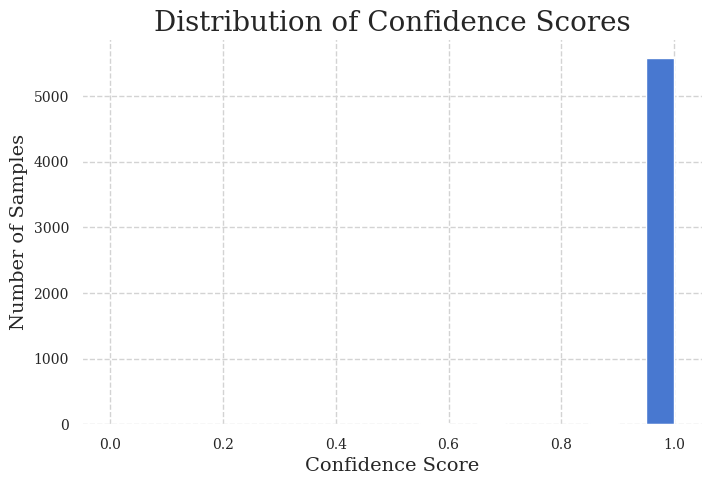

In [7]:
# plot the distribution of confidence scores
import matplotlib.pyplot as plt
from scripts import style
style.mpl_apply()  # Apply custom style setting 
plt.figure(figsize=(8,5))   
plt.hist(out["confidence"], bins=20, range=(0.0,1.0))
plt.title("Distribution of Confidence Scores")
plt.xlabel("Confidence Score")
plt.ylabel("Number of Samples")
plt.show()

In [8]:
import numpy as np, math, pandas as pd

# assumes: gamma (N,C), items (list), y_hat (list of class names), CLASSES
yhat_idx = np.argmax(gamma, axis=1)
p_correct = gamma[np.arange(gamma.shape[0]), yhat_idx]       # P(true == ŷ_i | votes)

acc_exp = float(p_correct.mean())
# Normal approx. SE for mean of independent Bernoullis with probs p_i
se = float(np.sqrt(np.sum(p_correct * (1 - p_correct))) / len(p_correct))
ci95 = (max(0.0, acc_exp - 1.96*se), min(1.0, acc_exp + 1.96*se))

print(f"Expected micro-accuracy: {acc_exp:.4f}")
print(f"Approx. 95% CI: [{ci95[0]:.4f}, {ci95[1]:.4f}]")


Expected micro-accuracy: 0.9969
Approx. 95% CI: [0.9957, 0.9981]


In [9]:
# Expected TP for class c: sum_i γ_ic * 1[ŷ_i == c]
# Expected support for class c: sum_i γ_ic
num = np.zeros(len(CLASSES))
den = np.zeros(len(CLASSES))
for c in range(len(CLASSES)):
    den[c] = float(np.sum(gamma[:, c]))
    num[c] = float(np.sum(gamma[yhat_idx == c, c]))
recalls = np.divide(num, np.clip(den, 1e-12, None))
bal_acc_exp = float(np.mean(recalls))

rec_df = pd.DataFrame({
    "class": CLASSES,
    "E[support]": den,
    "E[TP]": num,
    "E[recall_c]": recalls
})
display(rec_df)
print(f"Expected balanced accuracy: {bal_acc_exp:.4f}")


,class,E[support],E[TP],E[recall_c]
0,High,1106.385311,1105.993879,0.999646
1,Good,2006.488069,2003.290442,0.998406
2,Moderate,1648.805527,1640.424354,0.994917
3,Bad,565.890412,562.567164,0.994127
4,Poor,335.430682,333.011729,0.992789


Expected balanced accuracy: 0.9960


In [10]:
# M[c, l] = sum_i γ_ic * 1[ŷ_i = l];  row-normalize by E[support(c)]
K = len(CLASSES)
M = np.zeros((K, K))
for c in range(K):
    for l in range(K):
        M[c, l] = float(np.sum(gamma[yhat_idx == l, c]))
row_sums = M.sum(axis=1, keepdims=True)
M_rownorm = M / np.clip(row_sums, 1e-12, None)

conf_exp = pd.DataFrame(M_rownorm, index=[f"true:{c}" for c in CLASSES],
                                     columns=[f"pred:{c}" for c in CLASSES]).round(4)
display(conf_exp)


,pred:High,pred:Good,pred:Moderate,pred:Bad,pred:Poor
true:High,0.9996,0.0000,0.0000,0.0004,0.0000
true:Good,0.0000,0.9984,0.0016,0.0000,0.0000
true:Moderate,0.0000,0.0015,0.9949,0.0000,0.0036
true:Bad,0.0035,0.0023,0.0000,0.9941,0.0000
true:Poor,0.0000,0.0000,0.0072,0.0000,0.9928


In [11]:
# confidence_i = max_c γ_ic ; expected correctness equals p_correct
conf = p_correct.copy()
q = pd.qcut(conf, q=10, duplicates="drop")
cal = pd.DataFrame({"conf": conf, "p_correct": p_correct, "bin": q}) \
        .groupby("bin").agg(E_conf=("conf","mean"), E_acc=("p_correct","mean"),
                            count=("conf","size")).reset_index(drop=True)
display(cal)


C:\Users\herie\AppData\Local\Temp\ipykernel_13136\1667966124.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bin").agg(E_conf=("conf","mean"), E_acc=("p_correct","mean"),


,E_conf,E_acc,count
0,0.973584,0.973584,670
1,0.999990,0.999990,1160
2,0.999995,0.999995,441
3,0.999999,0.999999,699
4,1.000000,1.000000,547
5,1.000000,1.000000,635
6,1.000000,1.000000,382
7,1.000000,1.000000,1129


In [6]:
import pandas as pd
pred = pd.read_csv("results/011_Catboost_Regression_Full_t/011_Status.csv", index_col="SamplingOperations_code")

In [7]:
pred

,IBD_EQR_Status
SamplingOperations_code,
S02000010_20080811,Moderate
S02000010_20100719,Good
S02000010_20150811,Moderate
S02000010_20160825,Good
S02000010_20170703,Good
...,...
S06940940_20100708,Moderate
S06940940_20230623,Moderate
S06960950_20160629,High


In [9]:
yhat = pd.read_csv("notebooks/David-Skene EM/results/y_hat.csv", index_col="SamplingOperations_code")

In [10]:
# know the percentage of matching labels
import pandas as pd
# for tidy labels
tidy_label = {"High":"High","Good":"Good","Moderate":"Moderate","Bad":"Bad","Poor":"Poor"}
matches = (pred["IBD_EQR_Status"].map(tidy_label) == yhat["y_hat"])
accuracy = matches.mean()
accuracy

np.float64(0.8202366236976867)